<a href="https://colab.research.google.com/github/harshadbabar26-dev/HB1/blob/main/saudi_policy_anaysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

print(df.columns.tolist())

saudi = df[df["Country"]=="Saudi Arabia"].copy()

saudi = saudi.sort_values("Year")

saudi.tail()

['Country', 'Year', 'GDP', 'Inflation', 'Population', 'Migration', 'Migration_Flow', 'Oil_Price', 'Exchange_Rate', 'Unemployment', 'Kafala_Reform', 'Minimum_Wage_Law', 'Exit_Permit_Removal', 'World_Cup_Infrastructure_Program', 'Labor_Mobility_Reform', 'Saudization_Nitaqat', 'Vision2030', 'Labor_Reform_Initiative', 'Expat_Levy', 'Emiratisation_Policy', 'Golden_Visa', 'Entry_Residence_Law', 'Domestic_Workers_Law', 'Employment_Contract_Reform']


,Country,Year,GDP,Inflation,Population,Migration,Migration_Flow,Oil_Price,Exchange_Rate,Unemployment,...,Labor_Mobility_Reform,Saudization_Nitaqat,Vision2030,Labor_Reform_Initiative,Expat_Levy,Emiratisation_Policy,Golden_Visa,Entry_Residence_Law,Domestic_Workers_Law,Employment_Contract_Reform
106,Saudi Arabia,2022,1239.075,2.474074,32.175,1920793,170000,100.93,0.266667,5.590,...,0,1,1,1,1,0,0,0,0,0
107,Saudi Arabia,2023,1218.585,2.327085,33.703,1937144,195000,82.49,0.266667,5.007,...,0,1,1,1,1,0,0,0,0,0
108,Saudi Arabia,2024,1254.141,1.687921,35.300,1953496,210000,80.52,0.266667,5.007,...,0,1,1,1,1,0,0,0,0,0
109,Saudi Arabia,2025,1276.943,2.084209,36.006,2116570,210000,69.14,0.266667,5.007,...,0,1,1,1,1,0,0,0,0,0
110,Saudi Arabia,2026,1388.676,2.084209,36.726,2157114,210000,69.14,0.266667,5.007,...,0,1,1,1,1,0,0,0,0,0


In [ ]:
# /*#import statsmodels.api as sm

# #X = saudi[
# [
# "Population",
# "GDP",
# "Inflation",
# "Oil_Price",
# "Exchange_Rate",
# "Unemployment",
# policy
# ]
# ]

# y = saudi["Migration"]

# X = sm.add_constant(X)

# model = sm.OLS(y,X).fit()

# #print(model.summary())

In [ ]:
policy_year = saudi.loc[saudi[policy] == 1, "Year"].iloc[0]

print(policy_year)

NameError: name 'policy' is not defined

descriptive analysis for policy 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# Select Saudi Arabia
country = "Saudi Arabia"
saudi = df[df["Country"] == country].copy()

# -----------------------------
# CHANGE THIS TO YOUR POLICY
# -----------------------------
policy = "Saudization_Nitaqat"

# Policy year
policy_year = saudi.loc[saudi[policy] == 1, "Year"].min()

print("Policy Year:", policy_year)

# 3 years before
before = saudi[(saudi["Year"] >= policy_year-3) &
               (saudi["Year"] < policy_year)]

# All years after
after = saudi[saudi["Year"] >= policy_year]

before_avg = before["Migration"].mean()
after_avg = after["Migration"].mean()

print("Average Before:", before_avg)
print("Average After :", after_avg)
print("Difference:", after_avg-before_avg)

Policy Year: 2011
Average Before: 1452931.6666666667
Average After : 1892856.5
Difference: 439924.83333333326


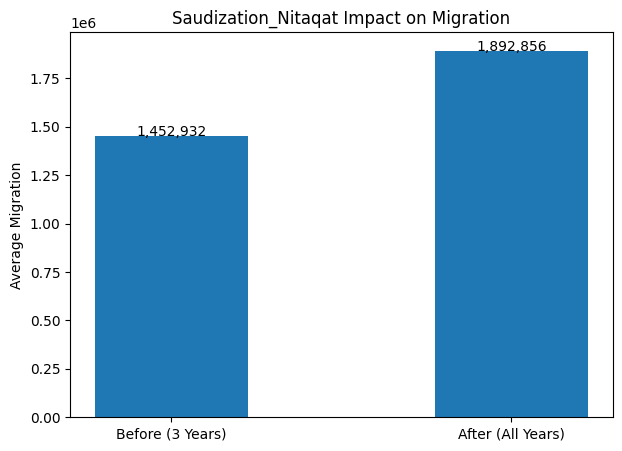

In [ ]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before (3 Years)", "After (All Years)"],
    [before_avg, after_avg],
    width=0.45
)

plt.ylabel("Average Migration")
plt.title(f"{policy} Impact on Migration")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center'
    )

plt.show()

multiple regression analysis for policy 1

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

economic = [
    "GDP",
    "Population",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]

X_scaled = StandardScaler().fit_transform(saudi[economic])

pca = PCA(n_components=2)

pcs = pca.fit_transform(X_scaled)

saudi["PC1"] = pcs[:,0]
saudi["PC2"] = pcs[:,1]

print("Explained Variance")
print(pca.explained_variance_ratio_)

Explained Variance
[0.57624041 0.23026637]


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(

    f"Migration ~ Population + PC1 + PC2 + {policy}",

    data=saudi

).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     549.7
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           5.39e-29
Time:                        12:28:36   Log-Likelihood:                -455.05
No. Observations:                  37   AIC:                             920.1
Df Residuals:                      32   BIC:                             928.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.369e+05   1

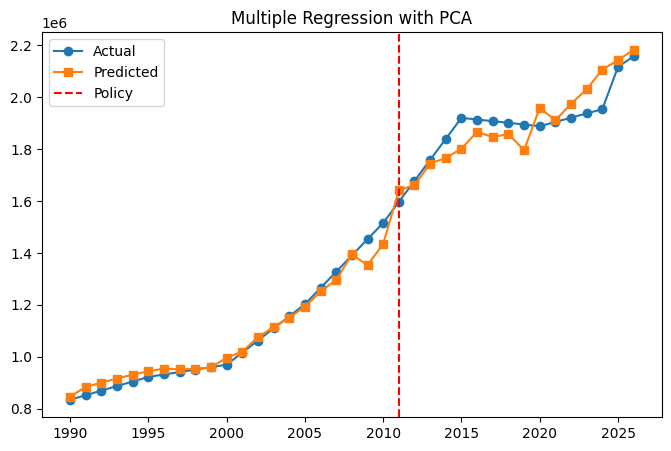

In [ ]:
saudi["Predicted"] = model.predict(saudi)

plt.figure(figsize=(8,5))

plt.plot(
    saudi["Year"],
    saudi["Migration"],
    marker='o',
    label="Actual"
)

plt.plot(
    saudi["Year"],
    saudi["Predicted"],
    marker='s',
    label="Predicted"
)

plt.axvline(policy_year,
            color='red',
            linestyle='--',
            label="Policy")

plt.legend()

plt.title("Multiple Regression with PCA")

plt.show()

ITS for policy1

In [ ]:
saudi = saudi.sort_values("Year")

saudi["Time"] = range(1, len(saudi)+1)

saudi["Policy"] = (saudi["Year"] >= policy_year).astype(int)

saudi["Time_After"] = (
    saudi["Year"] - policy_year
).clip(lower=0)

In [ ]:
its = smf.ols(

    "Migration ~ Time + Policy + Time_After",

    data=saudi

).fit()

print(its.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     502.1
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           1.35e-27
Time:                        12:28:43   Log-Likelihood:                -462.49
No. Observations:                  37   AIC:                             933.0
Df Residuals:                      33   BIC:                             939.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   7.198e+05   3.11e+04     23.146      0.0

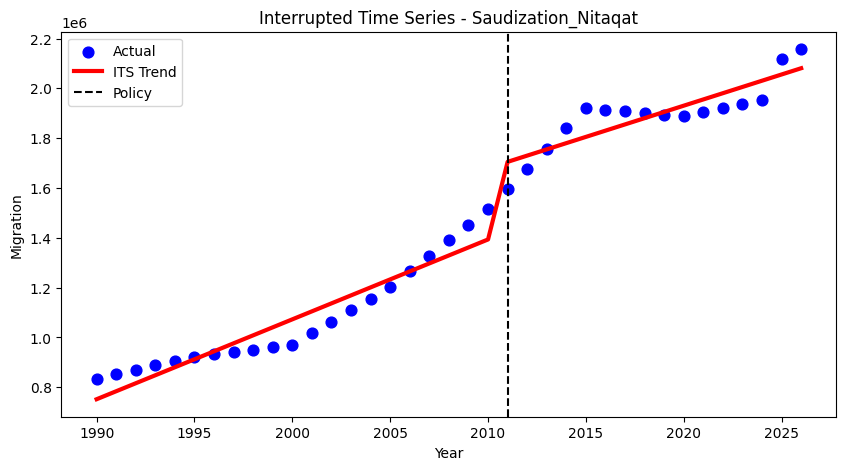

In [ ]:
saudi["ITS_Predicted"] = its.predict(saudi)

plt.figure(figsize=(10,5))

plt.scatter(
    saudi["Year"],
    saudi["Migration"],
    color='blue',
    s=60,
    label="Actual"
)

plt.plot(
    saudi["Year"],
    saudi["ITS_Predicted"],
    color='red',
    linewidth=3,
    label="ITS Trend"
)

plt.axvline(
    policy_year,
    linestyle="--",
    color="black",
    label="Policy"
)

plt.title(f"Interrupted Time Series - {policy}")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.legend()

plt.show()

policy number 2

descriptive analysis for policy 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

# Select Saudi Arabia
saudi = df[df["Country"] == "Saudi Arabia"].copy()

# Policy Name
policy = "Vision2030"

# Find Policy Year
policy_year = saudi.loc[saudi[policy] == 1, "Year"].min()

print("Vision2030 Policy Year:", policy_year)

# Three Years Before
before = saudi[
    (saudi["Year"] >= policy_year - 3) &
    (saudi["Year"] < policy_year)
]

# All Years After
after = saudi[
    saudi["Year"] >= policy_year
]

before_avg = before["Migration"].mean()
after_avg = after["Migration"].mean()

print("\nAverage Migration Before:", before_avg)
print("Average Migration After :", after_avg)
print("Increase:", after_avg - before_avg)

Vision2030 Policy Year: 2016

Average Migration Before: 1839235.0
Average Migration After : 1954013.3636363635
Increase: 114778.36363636353


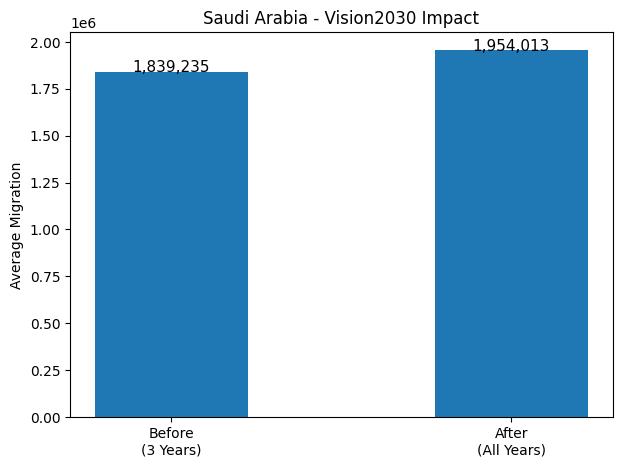

In [ ]:
plt.figure(figsize=(7,5))

bars = plt.bar(
    ["Before\n(3 Years)", "After\n(All Years)"],
    [before_avg, after_avg],
    width=0.45
)

plt.ylabel("Average Migration")
plt.title("Saudi Arabia - Vision2030 Impact")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha='center',
        fontsize=11
    )

plt.show()

multiple regression for policy 2

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

economic = [
   "GDP",

   "Population",
    "Inflation",
    "Oil_Price",
    "Exchange_Rate",
    "Unemployment"
]

X = saudi[economic]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

saudi["PC1"] = principal_components[:,0]
saudi["PC2"] = principal_components[:,1]

print("Explained Variance Ratio")
print(pca.explained_variance_ratio_)

Explained Variance Ratio
[0.57624041 0.23026637]


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(

    "Migration ~ Population + PC1 + PC2 + Vision2030",

    data=saudi

).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.984
Method:                 Least Squares   F-statistic:                     542.7
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.59e-29
Time:                        12:28:58   Log-Likelihood:                -455.29
No. Observations:                  37   AIC:                             920.6
Df Residuals:                      32   BIC:                             928.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -2.96e+05   1.36e+05     -2.180      0.0

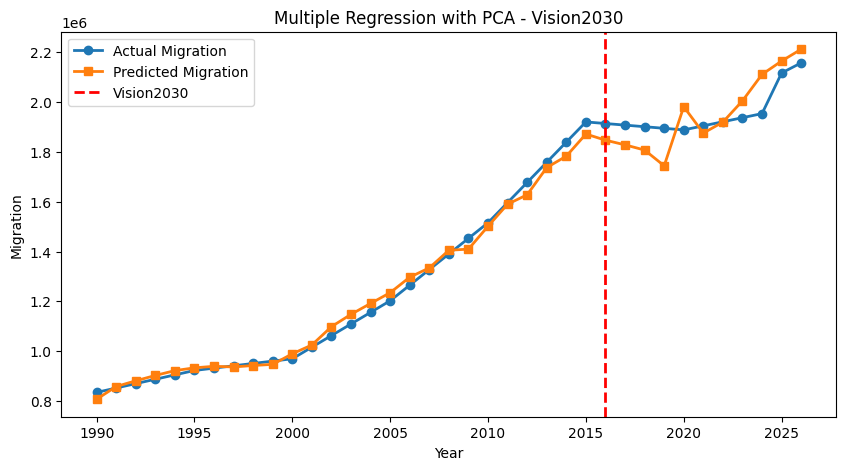

In [ ]:
saudi["Predicted"] = model.predict(saudi)

plt.figure(figsize=(10,5))

plt.plot(
    saudi["Year"],
    saudi["Migration"],
    marker="o",
    linewidth=2,
    label="Actual Migration"
)

plt.plot(
    saudi["Year"],
    saudi["Predicted"],
    marker="s",
    linewidth=2,
    label="Predicted Migration"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Vision2030"
)

plt.xlabel("Year")
plt.ylabel("Migration")
plt.title("Multiple Regression with PCA - Vision2030")
plt.legend()

plt.show()

ITS for policy 2

In [ ]:
saudi = saudi.sort_values("Year").copy()

saudi["Time"] = range(1, len(saudi)+1)

saudi["Policy"] = (saudi["Year"] >= policy_year).astype(int)

saudi["Time_After"] = (
    saudi["Year"] - policy_year
).clip(lower=0)

In [ ]:
its = smf.ols(

    "Migration ~ Time + Policy + Time_After",

    data=saudi

).fit()

print(its.summary())

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.960
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                     262.2
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           4.40e-23
Time:                        12:29:03   Log-Likelihood:                -474.15
No. Observations:                  37   AIC:                             956.3
Df Residuals:                      33   BIC:                             962.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   6.368e+05    3.8e+04     16.741      0.0

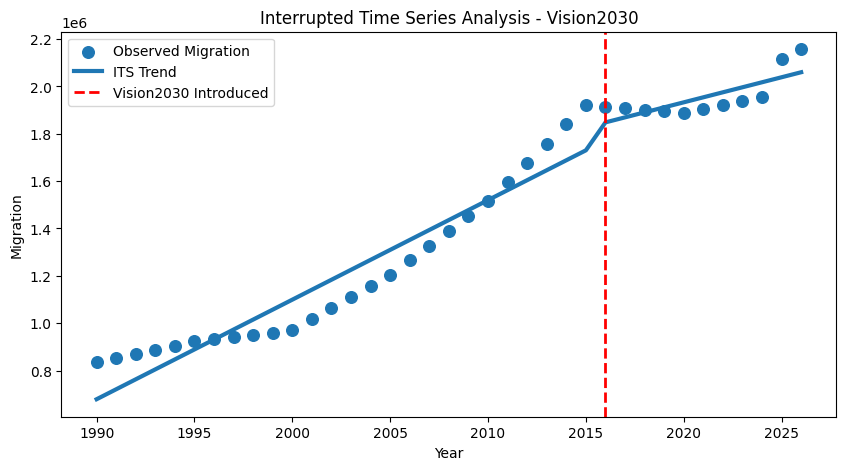

In [ ]:
saudi["ITS_Predicted"] = its.predict(saudi)

plt.figure(figsize=(10,5))

plt.scatter(
    saudi["Year"],
    saudi["Migration"],
    s=70,
    label="Observed Migration"
)

plt.plot(
    saudi["Year"],
    saudi["ITS_Predicted"],
    linewidth=3,
    label="ITS Trend"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Vision2030 Introduced"
)

plt.xlabel("Year")
plt.ylabel("Migration")
plt.title("Interrupted Time Series Analysis - Vision2030")
plt.legend()

plt.show()

descriptive analysis,multiple regression and ITS for policy 3

Policy : Labor_Reform_Initiative
Policy Year : 2021

DESCRIPTIVE ANALYSIS
----------------------------
Average Before : 1894504.0
Average After  : 1998259.83
Difference     : 103755.83


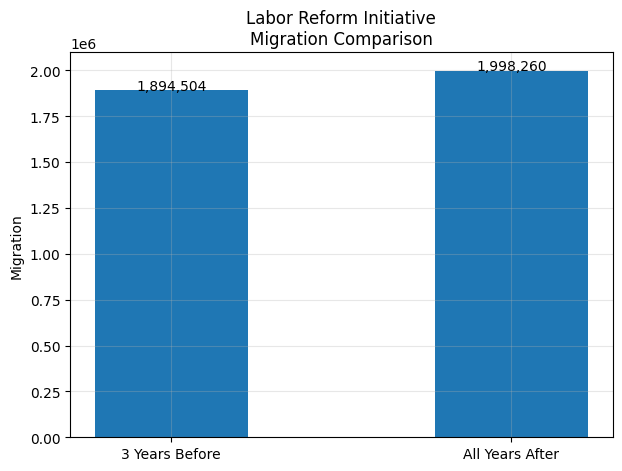

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                     672.3
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.70e-30
Time:                        12:29:10   Log-Likelihood:                -436.21
No. Observations:                  37   AIC:                             890.4
Df Residuals:                      28   BIC:                             904.9
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -3

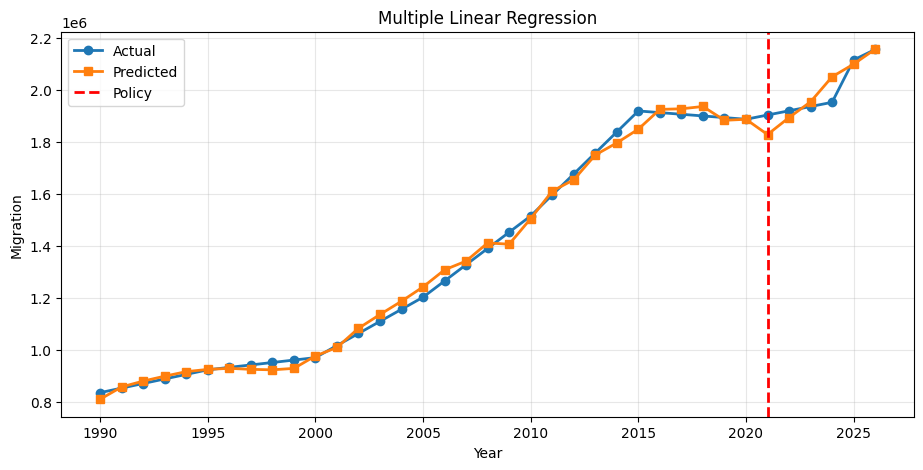

                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     593.7
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           4.82e-28
Time:                        12:29:11   Log-Likelihood:                -433.02
No. Observations:                  37   AIC:                             888.0
Df Residuals:                      26   BIC:                             905.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -2.809e+05   1.52e+05     -1.852

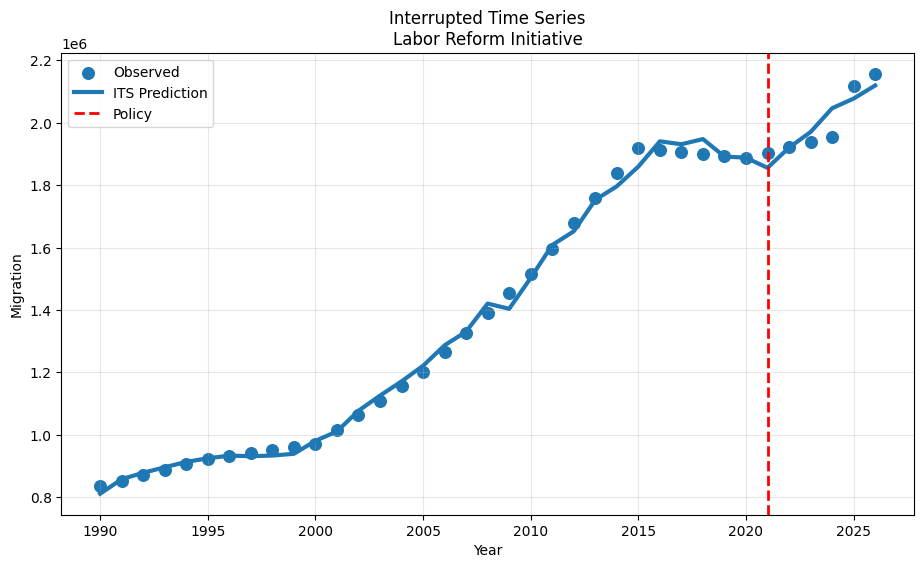

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

saudi = df[df["Country"]=="Saudi Arabia"].copy()

policy = "Labor_Reform_Initiative"

policy_year = saudi.loc[
    saudi[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :",policy)
print("Policy Year :",policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = saudi[
    (saudi.Year>=policy_year-3) &
    (saudi.Year<policy_year)
]

after = saudi[
    saudi.Year>=policy_year
]

before_avg = before["Migration"].mean()
after_avg = after["Migration"].mean()

print("\nDESCRIPTIVE ANALYSIS")
print("----------------------------")
print("Average Before :",round(before_avg,2))
print("Average After  :",round(after_avg,2))
print("Difference     :",round(after_avg-before_avg,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","All Years After"],
    [before_avg,after_avg],
    width=0.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center"
    )

plt.title("Labor Reform Initiative\nMigration Comparison")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.show()

# ======================================================
# STEP 2 : MULTIPLE REGRESSION
# ======================================================

# COVID Dummy
saudi["COVID"] = (saudi["Year"]>=2020).astype(int)

# Long-term Trend
saudi["Year_Index"] = saudi["Year"]-saudi["Year"].min()

model = smf.ols(

"""
Migration ~
Population +
GDP +
Inflation +
Oil_Price +
Exchange_Rate +
Unemployment +
Year_Index +
COVID +
Labor_Reform_Initiative
""",

data=saudi

).fit()

print(model.summary())

saudi["Prediction"] = model.predict(saudi)

print("\nRegression Performance")
print("----------------------------")
print("R² :",round(r2_score(saudi["Migration"],saudi["Prediction"]),4))
print("RMSE :",round(np.sqrt(mean_squared_error(
    saudi["Migration"],
    saudi["Prediction"])),2))

plt.figure(figsize=(11,5))

plt.plot(
    saudi["Year"],
    saudi["Migration"],
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    saudi["Year"],
    saudi["Prediction"],
    marker='s',
    linewidth=2,
    label="Predicted"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Policy"
)

plt.title("Multiple Linear Regression")
plt.xlabel("Year")
plt.ylabel("Migration")
plt.grid(alpha=.3)
plt.legend()
plt.show()

# ======================================================
# STEP 3 : IMPROVED ITS
# ======================================================

saudi = saudi.sort_values("Year")

saudi["Time"] = np.arange(1,len(saudi)+1)

saudi["Time2"] = saudi["Time"]**2

saudi["Policy"] = (
    saudi["Year"]>=policy_year
).astype(int)

saudi["Time_After"] = (
    saudi["Year"]-policy_year
).clip(lower=0)

its = smf.ols(

"""
Migration ~
Time +
Time2 +
Policy +
Time_After +
Population +
GDP +
Inflation +
Oil_Price +
Exchange_Rate +
Unemployment +
COVID
""",

data=saudi

).fit()

print(its.summary())

saudi["ITS_Prediction"] = its.predict(saudi)

print("\nITS Performance")
print("----------------------------")
print("R² :",round(r2_score(saudi["Migration"],saudi["ITS_Prediction"]),4))
print("RMSE :",round(np.sqrt(mean_squared_error(
    saudi["Migration"],
    saudi["ITS_Prediction"])),2))

plt.figure(figsize=(11,6))

plt.scatter(
    saudi["Year"],
    saudi["Migration"],
    s=70,
    label="Observed"
)

plt.plot(
    saudi["Year"],
    saudi["ITS_Prediction"],
    linewidth=3,
    label="ITS Prediction"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Policy"
)

plt.xlabel("Year")
plt.ylabel("Migration")
plt.title("Interrupted Time Series\nLabor Reform Initiative")
plt.grid(alpha=.3)
plt.legend()

plt.show()

4Th policy for all methods

Policy : Expat_Levy
Policy Year : 2017

DESCRIPTIVE ANALYSIS
----------------------------
Average Before : 1821767.6
Average After  : 1958040.2
Difference     : 136272.6


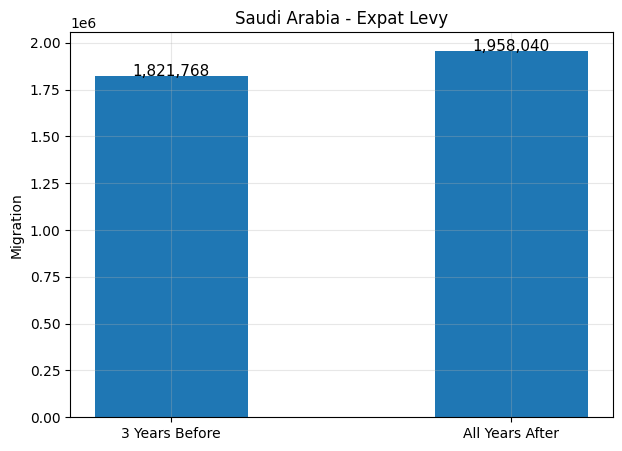


MULTIPLE REGRESSION
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                     726.4
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           2.28e-30
Time:                        12:31:07   Log-Likelihood:                -434.78
No. Observations:                  37   AIC:                             887.6
Df Residuals:                      28   BIC:                             902.1
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -2.719e+05 

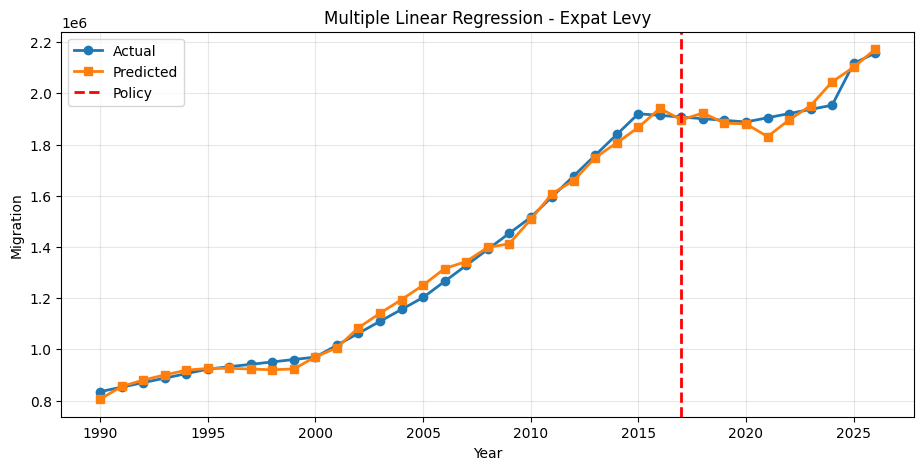


IMPROVED ITS
                            OLS Regression Results                            
Dep. Variable:              Migration   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     991.9
Date:                Sun, 02 Aug 2026   Prob (F-statistic):           6.28e-31
Time:                        12:31:07   Log-Likelihood:                -423.56
No. Observations:                  37   AIC:                             869.1
Df Residuals:                      26   BIC:                             886.8
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      3.489e+05   1.76e

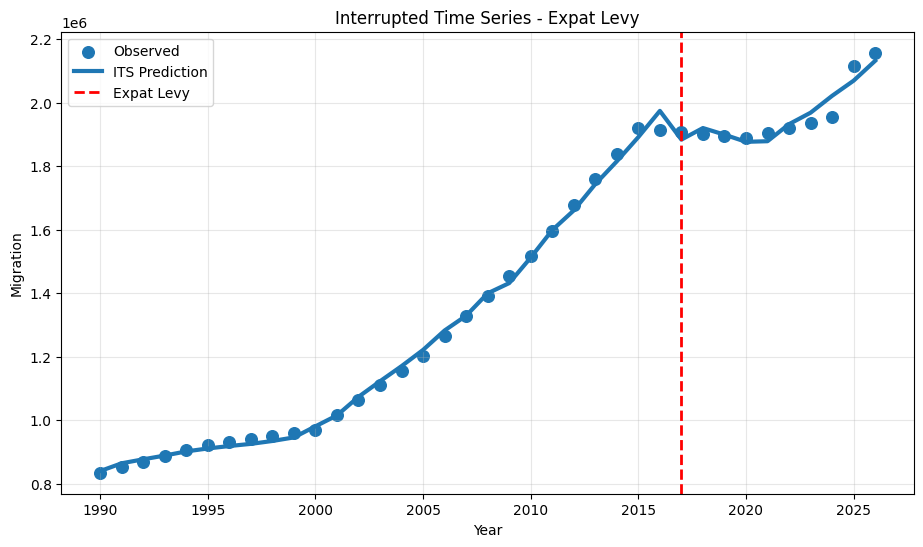

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score, mean_squared_error

# ======================================================
# LOAD DATA
# ======================================================

df = pd.read_excel("/content/Final_Master_Dataset_Cleaned (3).xlsx")

saudi = df[df["Country"]=="Saudi Arabia"].copy()

policy = "Expat_Levy"

policy_year = saudi.loc[
    saudi[policy]==1,
    "Year"
].min()

print("="*60)
print("Policy :",policy)
print("Policy Year :",policy_year)
print("="*60)

# ======================================================
# STEP 1 : DESCRIPTIVE ANALYSIS
# ======================================================

before = saudi[
    (saudi["Year"] >= policy_year-5) &
    (saudi["Year"] < policy_year)
]

after = saudi[
    saudi["Year"] >= policy_year
]

before_avg = before["Migration"].mean()
after_avg = after["Migration"].mean()

print("\nDESCRIPTIVE ANALYSIS")
print("----------------------------")
print("Average Before :", round(before_avg,2))
print("Average After  :", round(after_avg,2))
print("Difference     :", round(after_avg-before_avg,2))

plt.figure(figsize=(7,5))

bars = plt.bar(
    ["3 Years Before","All Years After"],
    [before_avg,after_avg],
    width=0.45
)

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():,.0f}",
        ha="center",
        fontsize=11
    )

plt.ylabel("Migration")
plt.title("Saudi Arabia - Expat Levy")
plt.grid(alpha=.3)

plt.show()

# ======================================================
# STEP 2 : MULTIPLE REGRESSION
# ======================================================

saudi["COVID"] = (saudi["Year"]>=2020).astype(int)

saudi["Year_Index"] = saudi["Year"] - saudi["Year"].min()

model = smf.ols(

"""
Migration ~
Population +
GDP +
Inflation +
Oil_Price +
Exchange_Rate +
Unemployment +
Year_Index +
COVID +
Expat_Levy
""",

data=saudi

).fit()

print("\nMULTIPLE REGRESSION")
print(model.summary())

saudi["Prediction"] = model.predict(saudi)

print("\nRegression Performance")
print("----------------------------")

print("R² :", round(r2_score(saudi["Migration"],
                            saudi["Prediction"]),4))

print("RMSE :", round(np.sqrt(mean_squared_error(
    saudi["Migration"],
    saudi["Prediction"])),2))

plt.figure(figsize=(11,5))

plt.plot(
    saudi["Year"],
    saudi["Migration"],
    marker='o',
    linewidth=2,
    label="Actual"
)

plt.plot(
    saudi["Year"],
    saudi["Prediction"],
    marker='s',
    linewidth=2,
    label="Predicted"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Policy"
)

plt.title("Multiple Linear Regression - Expat Levy")

plt.xlabel("Year")

plt.ylabel("Migration")

plt.grid(alpha=.3)

plt.legend()

plt.show()

# ======================================================
# STEP 3 : IMPROVED ITS
# ======================================================

saudi = saudi.sort_values("Year").copy()

saudi["Time"] = np.arange(1,len(saudi)+1)

saudi["Time2"] = saudi["Time"]**2

saudi["Policy"] = (
    saudi["Year"] >= policy_year
).astype(int)

saudi["Time_After"] = (
    saudi["Year"]-policy_year
).clip(lower=0)

its = smf.ols(

"""
Migration ~
Time +
Time2 +
Policy +
Time_After +
Population +
GDP +
Inflation +
Oil_Price +
Exchange_Rate +
Unemployment +
COVID
""",

data=saudi

).fit()

print("\nIMPROVED ITS")
print(its.summary())

saudi["ITS_Prediction"] = its.predict(saudi)

print("\nITS Performance")
print("----------------------------")

print("R² :", round(r2_score(saudi["Migration"],
                            saudi["ITS_Prediction"]),4))

print("RMSE :", round(np.sqrt(mean_squared_error(
    saudi["Migration"],
    saudi["ITS_Prediction"])),2))

plt.figure(figsize=(11,6))

plt.scatter(
    saudi["Year"],
    saudi["Migration"],
    s=70,
    label="Observed"
)

plt.plot(
    saudi["Year"],
    saudi["ITS_Prediction"],
    linewidth=3,
    label="ITS Prediction"
)

plt.axvline(
    policy_year,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Expat Levy"
)

plt.xlabel("Year")

plt.ylabel("Migration")

plt.title("Interrupted Time Series - Expat Levy")

plt.grid(alpha=.3)

plt.legend()

plt.show()